In [1]:
import os

In [2]:
%pwd

'c:\\Users\\Hp\\Desktop\\cifar10-image-classificatio\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\Hp\\Desktop\\cifar10-image-classificatio'

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [6]:
from pathlib import Path
import tensorflow as tf

model_path = Path(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\training\model.h5")

model = tf.keras.models.load_model(model_path)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [7]:
from pathlib import Path
import numpy as np

data_path = Path(r"C:\Users\Hp\Desktop\artifacts\data_ingestion")

X_train = np.load(data_path / "X_train.npy")
y_train = np.load(data_path / "y_train.npy")

print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [8]:
from pathlib import Path
import numpy as np

data_path = Path(r"C:\Users\Hp\Desktop\artifacts\data_ingestion")

X_test = np.load(data_path / "X_test.npy")
y_test = np.load(data_path / "y_test.npy")

print(X_test.shape)
print(y_test.shape)

(10000, 32, 32, 3)
(10000, 1)


In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 [==============================] - 28s 86ms/step - loss: 0.7079 - accuracy: 0.8493
Test Loss     : 0.7079
Test Accuracy : 0.8493


In [10]:
predictions = model.predict(X_test)

y_pred_classes = np.argmax(
    predictions,
    axis=1
)

y_true = y_test

313/313 [==============================] - 29s 91ms/step


In [11]:
from sklearn.metrics import classification_report

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.85      0.88      0.86      1000
  Automobile       0.94      0.91      0.93      1000
        Bird       0.85      0.73      0.78      1000
         Cat       0.69      0.72      0.71      1000
        Deer       0.82      0.87      0.85      1000
         Dog       0.81      0.75      0.78      1000
        Frog       0.84      0.91      0.87      1000
       Horse       0.94      0.85      0.89      1000
        Ship       0.91      0.93      0.92      1000
       Truck       0.86      0.93      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

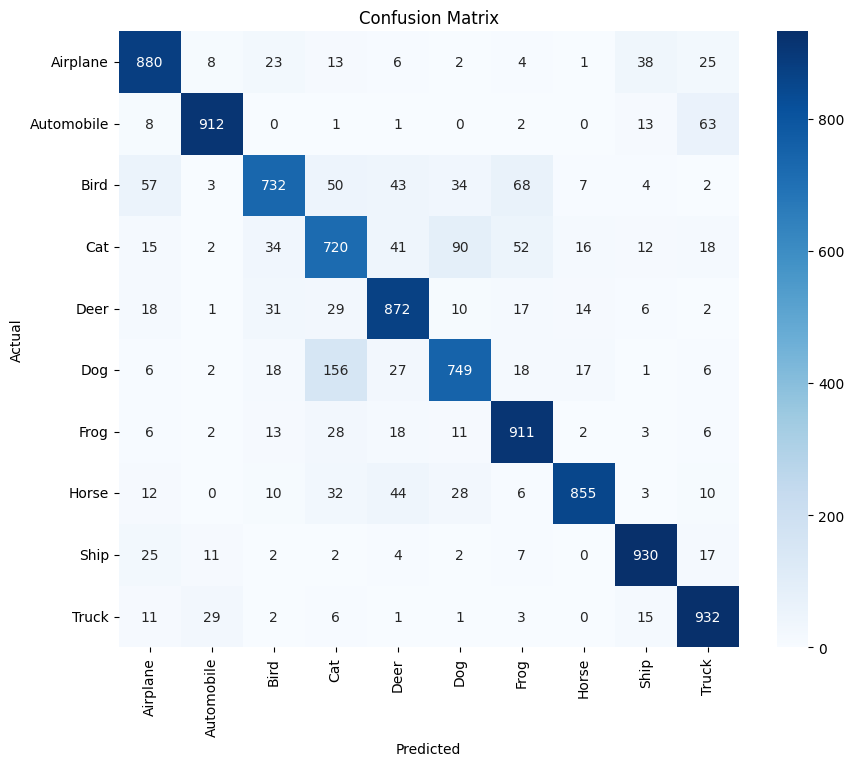

In [13]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [14]:
history = model.history.history

In [18]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\training\model.h5")

print(model.input_shape)
print(model.output_shape)
model.summary()

(None, 32, 32, 3)
(None, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                           

In [19]:
pred = model.predict(X_test[:5], verbose=0)

print("Predicted:", np.argmax(pred, axis=1))
print("Actual:", y_test[:5].flatten())

Predicted: [3 8 8 0 6]
Actual: [3 8 8 0 6]


In [20]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(acc)

0.8493000268936157


In [21]:
import numpy as np

X_train = np.load(r"C:\Users\Hp\Desktop\artifacts\data_ingestion\X_train.npy")

print(X_train.dtype)
print("Min:", X_train.min())
print("Max:", X_train.max())

uint8
Min: 0
Max: 255


In [22]:
from PIL import Image
import numpy as np

img = Image.open(r"C:\Users\Hp\Desktop\imagesq.jpg").convert("RGB")
img = img.resize((32,32))

x = np.array(img).astype("float32")/255.0
x = np.expand_dims(x,0)

pred = model.predict(x,verbose=0)

print(pred)


[[1.6395129e-02 8.7217850e-05 3.9839573e-02 8.8362676e-01 3.1811103e-02
  9.4797630e-03 7.8910841e-03 8.9818914e-04 9.6198833e-03 3.5129627e-04]]


In [23]:
print(np.argmax(pred))

3


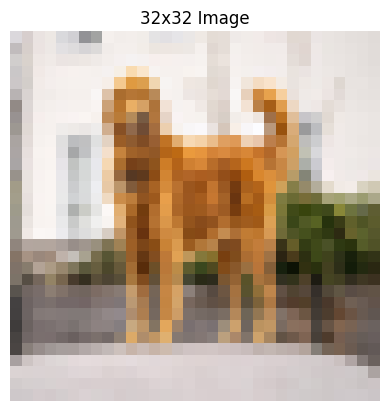

Shape: (32, 32, 3)
Dtype: uint8
Min: 5
Max: 255
Final Shape: (1, 32, 32, 3)
Probabilities:
[[1.6395129e-02 8.7217850e-05 3.9839573e-02 8.8362676e-01 3.1811103e-02
  9.4797630e-03 7.8910841e-03 8.9818914e-04 9.6198833e-03 3.5129627e-04]]
Predicted Class: 3
Confidence: 0.88362676


In [24]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open(r"C:\Users\Hp\Desktop\imagesq.jpg").convert("RGB")

# Resize to CIFAR-10 size
img = img.resize((32, 32))

# Show resized image
plt.imshow(img)
plt.title("32x32 Image")
plt.axis("off")
plt.show()

# Convert to NumPy
x = np.array(img)

print("Shape:", x.shape)
print("Dtype:", x.dtype)
print("Min:", x.min())
print("Max:", x.max())

# Normalize
x = x.astype("float32") / 255.0

# Add batch dimension
x = np.expand_dims(x, axis=0)

print("Final Shape:", x.shape)

# Prediction
pred = model.predict(x, verbose=0)

print("Probabilities:")
print(pred)

print("Predicted Class:", np.argmax(pred))
print("Confidence:", np.max(pred))

In [25]:
print(class_names[np.argmax(pred)])
print(np.max(pred))
print(pred)

Cat
0.88362676
[[1.6395129e-02 8.7217850e-05 3.9839573e-02 8.8362676e-01 3.1811103e-02
  9.4797630e-03 7.8910841e-03 8.9818914e-04 9.6198833e-03 3.5129627e-04]]


In [26]:
print("Image Sum:", np.sum(x))
print("Image Mean:", np.mean(x))
print("Image Std:", np.std(x))

Image Sum: 1962.3176
Image Mean: 0.6387753
Image Std: 0.27001315


In [28]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\training\model.h5")

pred = model.predict(X_test[:20], verbose=0)

print("Predicted :", np.argmax(pred, axis=1))
print("Actual    :", y_test[:20].flatten())

Predicted : [3 8 8 0 6 6 9 6 3 1 0 9 5 7 9 8 5 7 8 6]
Actual    : [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


In [29]:
print(model.layers[-1].activation.__name__)

softmax


In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Load history
history_path = Path(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\training\history.json")

with open(history_path, "r") as f:
    history = json.load(f)

print(history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


Accuracy Curve

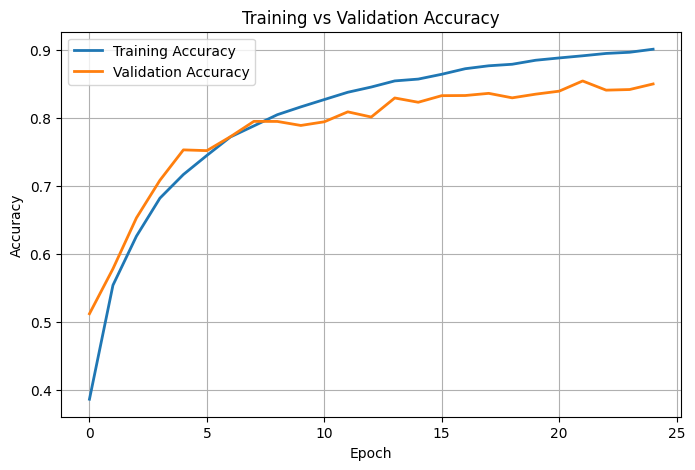

In [3]:
plt.figure(figsize=(8,5))

plt.plot(history["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Loss Curve

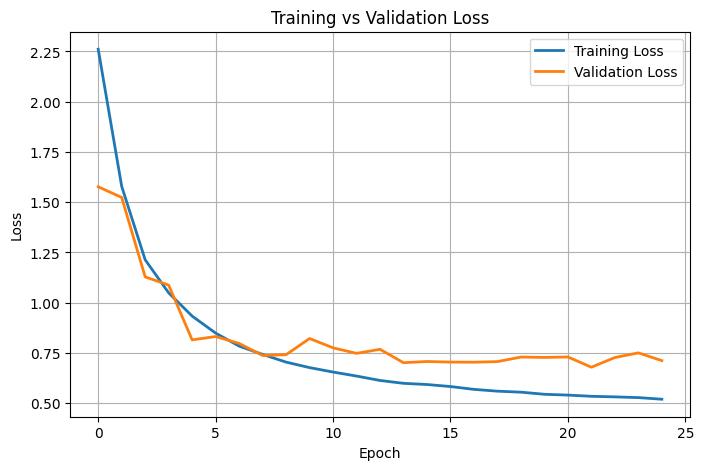

In [4]:
plt.figure(figsize=(8,5))

plt.plot(history["loss"], label="Training Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

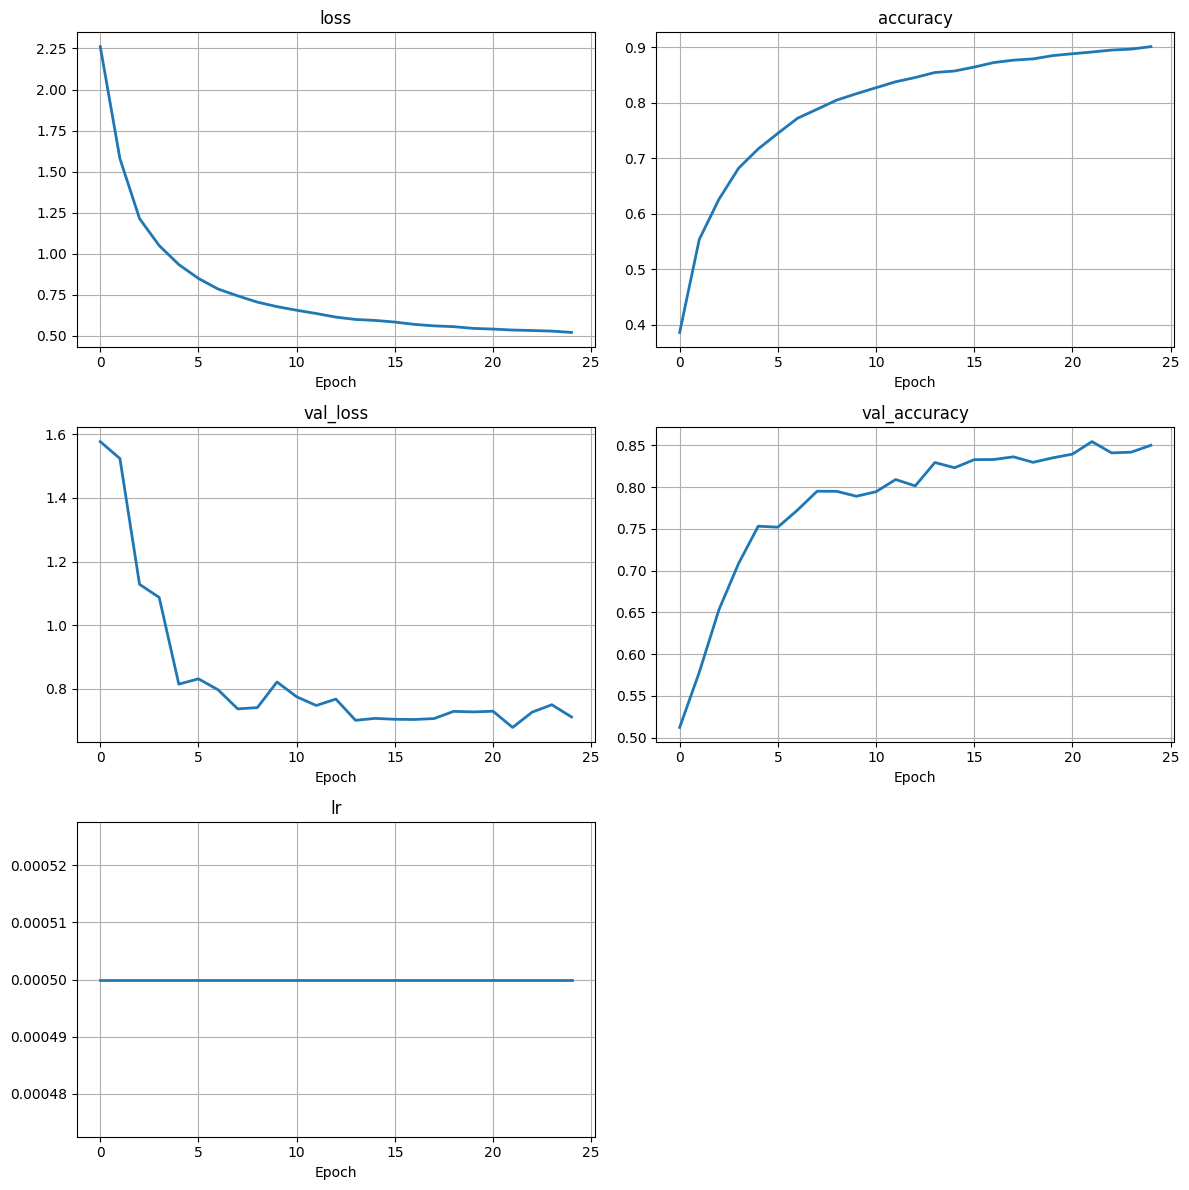

In [5]:
import math

metrics = list(history.keys())

rows = math.ceil(len(metrics) / 2)

plt.figure(figsize=(12, rows * 4))

for i, metric in enumerate(metrics):
    plt.subplot(rows, 2, i + 1)
    plt.plot(history[metric], linewidth=2)
    plt.title(metric)
    plt.xlabel("Epoch")
    plt.grid(True)

plt.tight_layout()
plt.show()

Due to hardware limitations, the model could not be trained for additional epochs or extensively tuned. With access to more powerful computational resources (e.g., a dedicated GPU), the model could be trained for more epochs while applying appropriate techniques such as learning rate scheduling, early stopping, and regularization. This would likely improve overall performance, reduce overfitting, and enhance the model's ability to generalize to unseen data.